In [1]:
import os
import openai
import duckdb
import pandas as pd
import time
import json
import re

duckdb.sql("""
           CREATE OR REPLACE TABLE component AS
           SELECT "ch.chat_id" AS chat_id, "ch.componentID" as comp_id
           FROM read_csv('analysis_data/chats_graph/all_components.csv')
           """)

duckdb.sql("""
           CREATE OR REPLACE TABLE chats_all AS
           SELECT chat_id, text_content, start_time
           FROM read_csv('preprocess_data/chat_nodes.csv')
           """)

duckdb.sql("""
           CREATE OR REPLACE TABLE chats AS
           SELECT b.chat_id as chat_id, b.text_content as text_content,
           a.comp_id as comp_id, b.start_time as start_time
           FROM component as a, chats_all as b
           WHERE a.chat_id == b.chat_id
           """)

In [2]:
df = duckdb.sql("SELECT * FROM chats").df()

In [3]:
total_chars = int(df['text_content'].str.len().sum())
total_words = int(df['text_content'].str.split().str.len().sum())
print(total_chars, total_words)

346399797 53253791


In [4]:
client = openai.OpenAI(api_key=os.environ.get("MARITACA_API_KEY"),
                       base_url="https://chat.maritaca.ai/api")

prompt_system = """Você é um classificador de desinformação. Analise o texto fornecido e classifique o assunto principal na melhor categoria. Sua resposta deve conter o número de uma das categorias, somente o número.

1. Política e Eleições: Fraude em urnas, ataque a instituições públicas.
2. Economia: Impostos, inflação, crise, PIX, Bolsa Família, financiamento.
3. Saúde e Ciência: Vacinas, tratamentos, alimentação, crise sanitária, pseudociências, ceticismo sobre ciência.
4. Segurança e Golpes: Link de prêmio, alarmismo sobre crimes e golpes.
5. Sociedade: Preconceitos, discriminação de minorias, pessoas e etnias.
6. Calamidades: Invasão, apocalipse, guerra.
7. Indeterminado: apenas se não houver relação com algum assunto anterior.
"""

In [5]:
def batch_jsonl(df, chunk_size=40000, file_prefix="chats_batch"):
    current_file_idx = 0
    written_lines = 0
    file = None

    try:
        for row in df.itertuples(index=False):

            if written_lines == 0:
                filename = f"analysis_data/chats_graph/api_batch/{file_prefix}_{current_file_idx}.jsonl"
                file = open(filename, "w", encoding="utf-8")

            req = {
                "custom_id": str(row.chat_id),
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": "sabia-4",
                    "messages": [
                        {"role": "system", "content": prompt_system},
                        {"role": "user", "content": str(row.text_content)},
                    ],
                    "max_tokens": 5,
                    "tools": [],
                    "temperature": 0.0,
                },
            }

            line = json.dumps(req, ensure_ascii=False)
            file.write(line + "\n")
            written_lines += 1

            if written_lines >= chunk_size:
                file.close()
                file = None
                current_file_idx += 1
                written_lines = 0

    finally:
        if file is not None:
            file.close()

def get_response(string):
    for attempt in range(1,6):
        try:
            response = client.chat.completions.create(
                model="sabia-4",
                messages=[
                    {"role": "system", "content": prompt_system},
                    {"role": "user", "content": string}
                ],
                tools=[],
                max_tokens=5,
                stream=False,
                temperature=0.0
            )
            return response
        except openai.RateLimitError:
            print("HTTP 429, attempt", attempt)
            time.sleep(2*attempt)
    raise Exception

def run_api(classification, df):
    i = 1
    for string in df['text_content']:
        try:
            res = get_response(string)
        except Exception:
            print("Stopping. Failed at index", i)
            return
        classification.append(res.choices[0].message.content)
        time.sleep(1.0)
        i += 1

In [6]:
#via batch api (manual upload)
#df = duckdb.sql("SELECT * FROM chats").df()
#batch_jsonl(df)

#via api requisitions
#classification = []
#run_api(classification, df)

In [7]:
def add_content_classification(df, file_paths_list):
    classifications = {}

    for response_file_path in file_paths_list:
        with open(response_file_path, "r", encoding="utf-8") as file:
            for line in file:
                data = json.loads(line.strip())

                custom_id = int(data["custom_id"])
                content = data["response"]["body"]["choices"][0]["message"]["content"]
                if content is None:
                    classifications[custom_id] = 7 # mark exceptions as undetermined
                    continue
                content = content.strip()
                content = re.findall(r'\d', content) # filter digits only
                
                # Exactly one digit must be present for the answer to be valid, and be between 1 and 7
                if (len(content) == 1) and (content[0] in ["1", "2", "3", "4", "5", "6", "7"]):
                    classifications[custom_id] = int(content[0])
                else:
                    classifications[custom_id] = 7 # mark exceptions as undetermined
    
    df["content_classification"] = df["chat_id"].map(classifications)

    return df

In [8]:
base_folder = "analysis_data/chats_graph/api_batch/result_batch_"
responses = [base_folder + str(x) + ".jsonl" for x in range(0, 3)]

df = add_content_classification(df, responses)
df = df.drop(columns="text_content")

df.to_csv('analysis_data/chats_graph/chats_llm_classification.csv', index=False, encoding='utf-8')

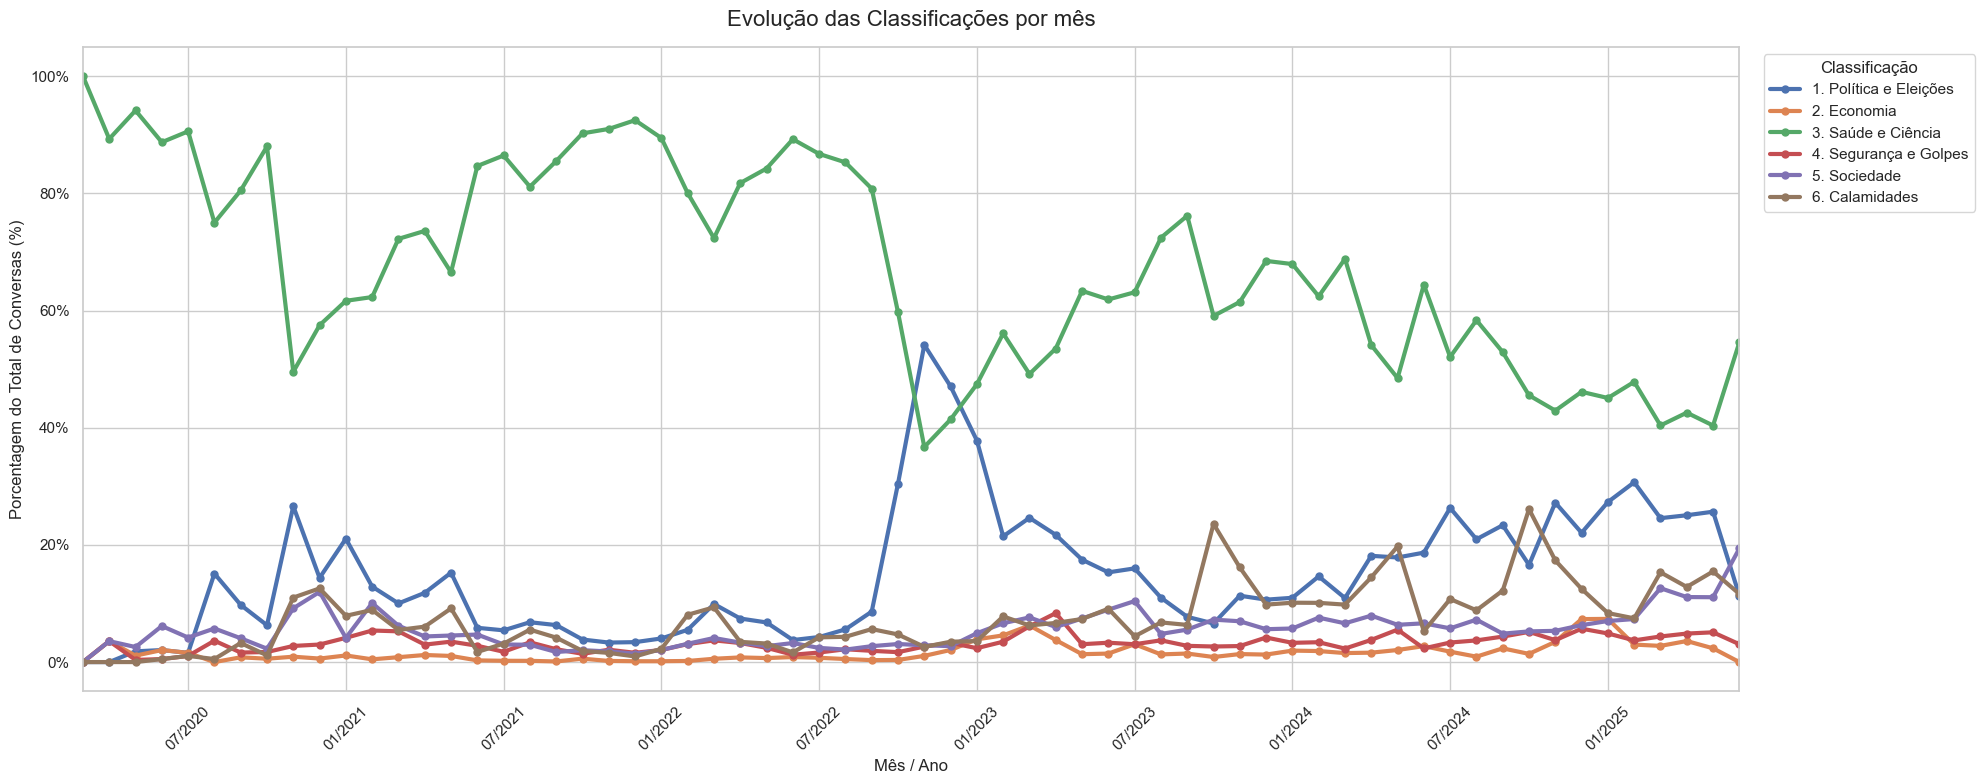

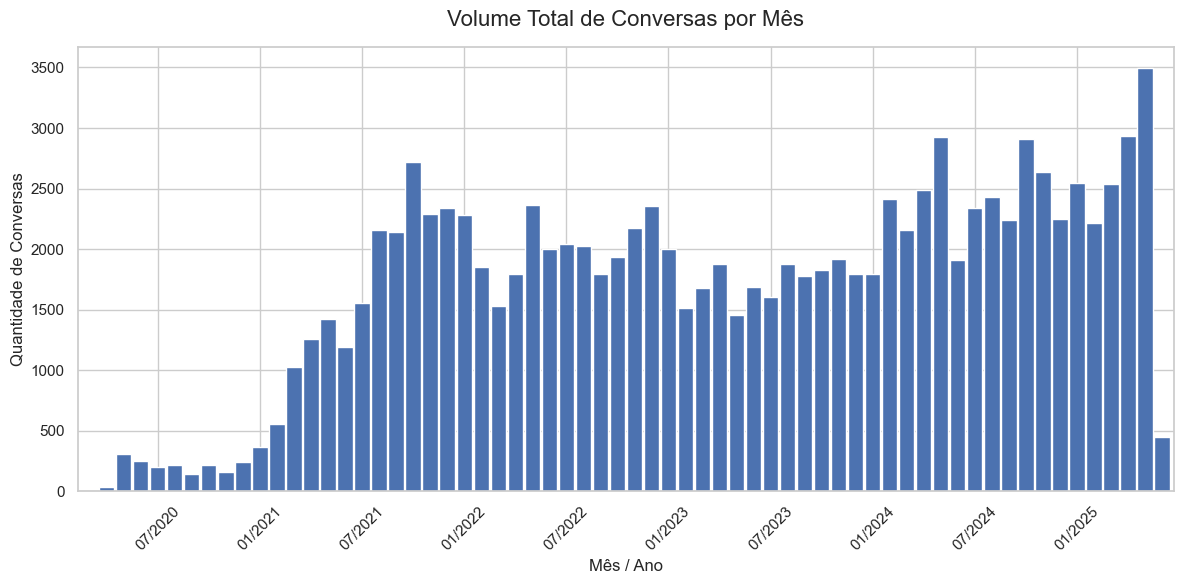

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def plot_classification(df, custom_title):
    sns.set_theme(style="whitegrid")

    df['date'] = pd.to_datetime(df['start_time'], unit='s')
    df['month_year'] = df['date'].dt.to_period('M')

    df_not7 = df[df['content_classification'] != 7].copy()
    
    monthly_counts_not7 = df_not7.groupby(['month_year', 'content_classification']).size().unstack(fill_value=0)

    monthly_percentages_not7 = monthly_counts_not7.div(monthly_counts_not7.sum(axis=1), axis=0) * 100
    
    cols_to_plot_not7 = [col for col in monthly_percentages_not7.columns if col in [1, 2, 3, 4, 5, 6, 7]]
    
    plot_data_not7 = monthly_percentages_not7[cols_to_plot_not7]
    plot_data_not7.index = plot_data_not7.index.strftime('%m/%Y')
    
    label_mapping = {
        1: '1. Política e Eleições',
        2: '2. Economia',
        3: '3. Saúde e Ciência',
        4: '4. Segurança e Golpes',
        5: '5. Sociedade',
        6: '6. Calamidades'
    }
    plot_data_not7 = plot_data_not7.rename(columns=label_mapping)

    plt.figure(figsize=(20, 8))
    plot_data_not7.plot(ax=plt.gca(), marker='o', linewidth=3, markersize=5)
    plt.title(custom_title, fontsize=16, pad=15)
    plt.xlabel('Mês / Ano', fontsize=12)
    plt.ylabel('Porcentagem do Total de Conversas (%)', fontsize=12)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.legend(title='Classificação', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    ticks = [i for i, val in enumerate(plot_data_not7.index) if val.startswith('01/') or val.startswith('07/')]
    labels = [plot_data_not7.index[i] for i in ticks]
    plt.xticks(ticks, labels, rotation=45)
    plt.xlim(0, len(plot_data_not7.index) - 1)
    
    plt.tight_layout()
    plt.show()

def plot_quantity(df):
    total_per_month = df.groupby('month_year').size()
    total_per_month.index = total_per_month.index.strftime('%m/%Y')
    
    plt.figure(figsize=(12, 6))
    total_per_month.plot(kind='bar', color='#4C72B0', ax=plt.gca(), width=0.9)
    plt.title('Volume Total de Conversas por Mês', fontsize=16, pad=15)
    plt.xlabel('Mês / Ano', fontsize=12)
    plt.ylabel('Quantidade de Conversas', fontsize=12)
    
    ticks_bar = [i for i, val in enumerate(total_per_month.index) if val.startswith('01/') or val.startswith('07/')]
    labels_bar = [total_per_month.index[i] for i in ticks_bar]
    plt.xticks(ticks_bar, labels_bar, rotation=45)

    plt.tight_layout()
    plt.show()

plot_classification(df, 'Evolução das Classificações por mês')
plot_quantity(df)

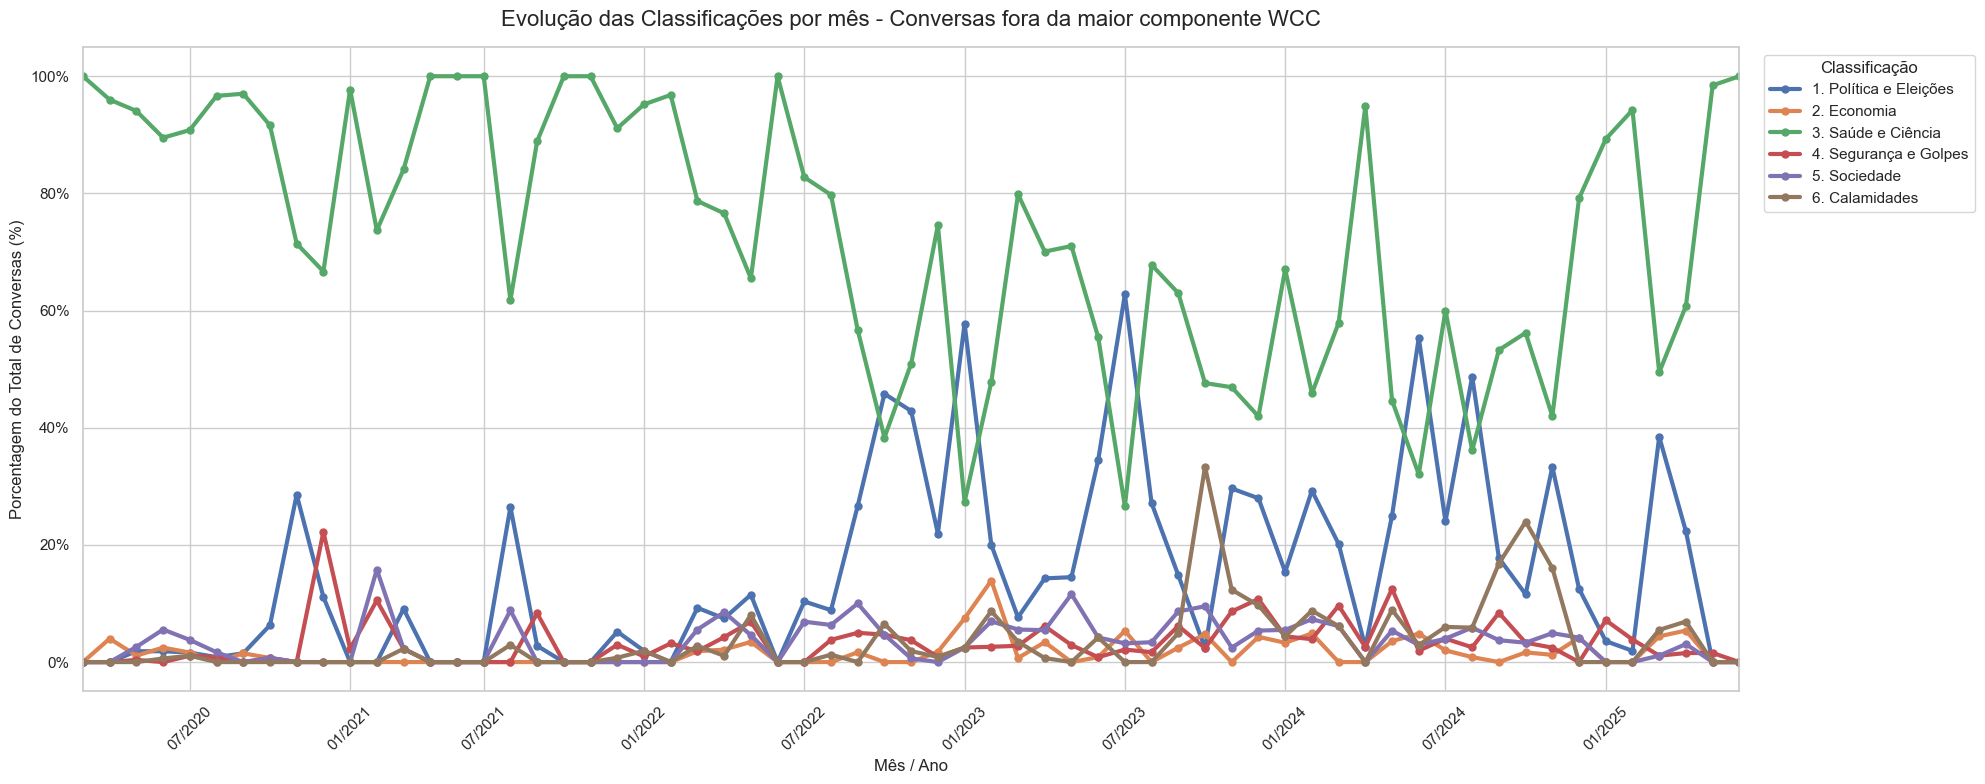

In [21]:
df_component0 = df[df['comp_id'] != 0]
plot_classification(df_component0, 'Evolução das Classificações por mês - Conversas fora da maior componente WCC')